In [1]:
import micropip
await micropip.install("seaborn")

In [2]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('train.csv')

# Titanic Survival Analysis

## 1. Introduction

### Project Objective
The goal of this project is to analyze the factors that influenced passenger survival on the Titanic using exploratory data analysis (EDA), feature engineering, and statistical interpretation. The analysis focuses on identifying how demographic, socioeconomic, and behavioral factors impacted survival outcomes.

### Research Question
> What factors most strongly influenced a passenger’s likelihood of survival aboard the Titanic?

### Dataset Overview
The dataset contains passenger information from the Titanic disaster, including:

- Demographic information (age, gender)
- Socioeconomic indicators (ticket fare, passenger class)
- Family structure information
- Survival outcomes

### Tools & Technologies
- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib
- Jupyter Notebook

---

# 2. Data Cleaning

## Objective
Prepare the dataset for analysis by handling missing values, removing inconsistencies, and validating data quality.

## Missing Value Analysis
The dataset was evaluated for missing values across all columns.

### Key Findings
- `Age` contained missing values and was imputed using the median age.
- `Embarked` contained a small number of missing values and was filled using the mode.
- `Cabin` contained a large proportion of missing values and was converted into a binary feature (`HasCabin`) before being removed.

## Duplicate Check
The dataset was checked for duplicate records using:

In [4]:
df.duplicated().any()

np.False_

No significant duplicate issues were identified.

## Data Cleaning Code

In [5]:
# Fill missing age values
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing embarked values
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Create HasCabin feature
df['HasCabin'] = df['Cabin'].notna()

# Drop Cabin column
df.drop(columns=['Cabin'], inplace=True)

df.head()

<ipython-input-5-f3092e567f1d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
<ipython-input-5-f3092e567f1d>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,False


---

# 3. Feature Engineering

## Objective
Create additional variables to improve analytical depth and capture meaningful passenger characteristics.

## Features Created

### Family Size
Measures the total number of family members traveling together.

In [12]:
 df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

### IsAlone
Indicates whether the passenger was traveling alone.

In [13]:
 df['IsAlone'] = df['FamilySize'] == 1

### Age Groups
Passengers were grouped into age categories for comparison.

In [10]:
 df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0,12,18,35,60,100],
                         labels=['Child','Teen','YoungAdult','Adult','Senior'])

### Log Fare
A log transformation was applied to normalize the fare distribution. Without this the data would be skewed heavily.

In [9]:
 df['LogFare'] = np.log1p(df['Fare'])

---

# 4. Gender Analysis

## Objective
Evaluate whether gender influenced survival outcomes.

## Visualization

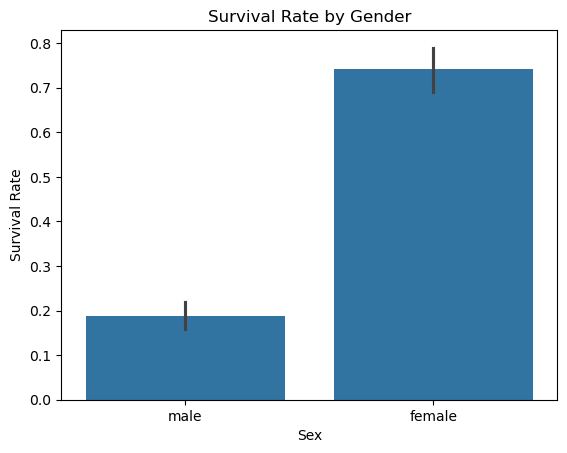

In [6]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

## Key Findings
- Female passengers had significantly higher survival rates.
- Male passengers experienced substantially lower survival outcomes.

## Interpretation
The analysis suggests that gender was one of the strongest predictors of survival. Female passengers were prioritized during evacuation procedures, consistent with the historical “women and children first” policy.

---

# 5. Class Analysis

## Objective
Determine whether passenger class influenced survival probability.

## Visualization

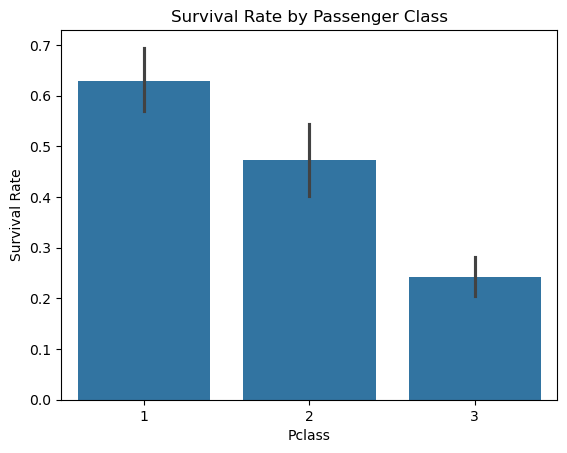

In [14]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

## Key Findings
- First-class passengers had the highest survival rates.
- Third-class passengers had the lowest survival rates.

## Interpretation
Passenger class strongly influenced survival outcomes, suggesting that socioeconomic status and physical access to lifeboats likely played important roles during evacuation.

---

# 6. Age Analysis

## Objective
Analyze the relationship between age and survival outcomes.

## Visualization

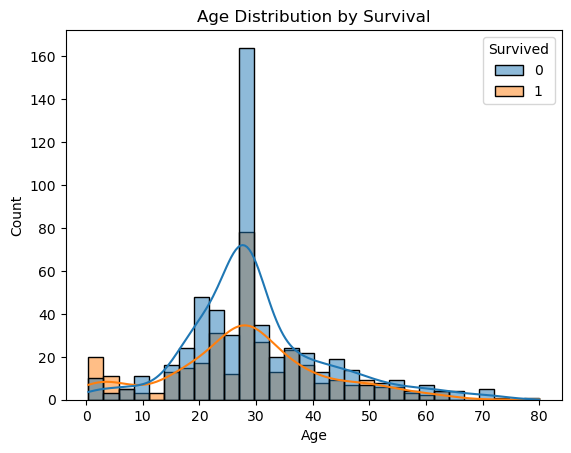

In [7]:
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Age Distribution by Survival')
plt.show()

## Key Findings
- Children demonstrated relatively higher survival representation.
- Adults between approximately 20–40 years made up the majority of non-survivors.
- Older passengers showed lower survival representation.

## Interpretation
The results suggest that age influenced survival outcomes, particularly for younger passengers. However, significant overlap between survivor and non-survivor age distributions indicates that age alone did not determine survival.

---

# 7. Family Analysis

## Objective
Examine whether family structure impacted survival probability.

## Visualization

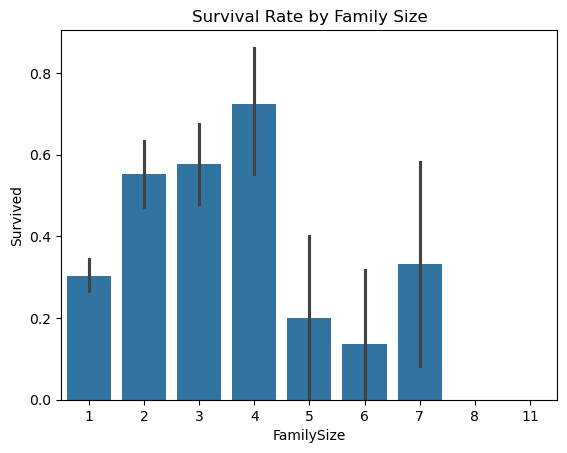

In [15]:
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

## Key Findings
- Small family groups showed higher survival rates.
- Large family groups experienced reduced survival outcomes.
- Passengers traveling alone generally had lower survival rates.

## Interpretation
Family structure appears to influence survival outcomes. Small groups may have benefited from social support during evacuation, while larger groups likely faced coordination difficulties.

---

# 8. Fare Analysis

## Objective
Determine whether ticket fare, as a proxy for wealth, influenced survival outcomes.

## Visualization

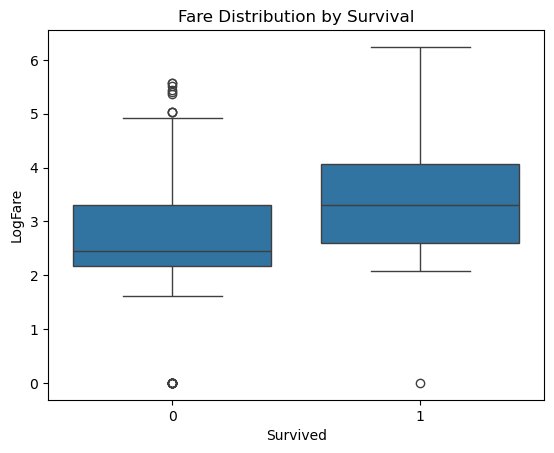

In [16]:
sns.boxplot(x='Survived', y='LogFare', data=df)
plt.title('Fare Distribution by Survival')
plt.show()

## Key Findings
- Survivors exhibited higher median fares.
- High-fare passengers were more strongly represented among survivors.
- Significant overlap still exists between the two groups.

## Interpretation
Passengers paying higher fares generally experienced improved survival outcomes, suggesting that wealth and access influenced rescue opportunities. However, fare alone does not fully explain survival outcomes and is partially confounded by passenger class.

---

# 9. Combined Effects

## Objective
Analyze how multiple variables interacted to influence survival outcomes.

## Gender and Class

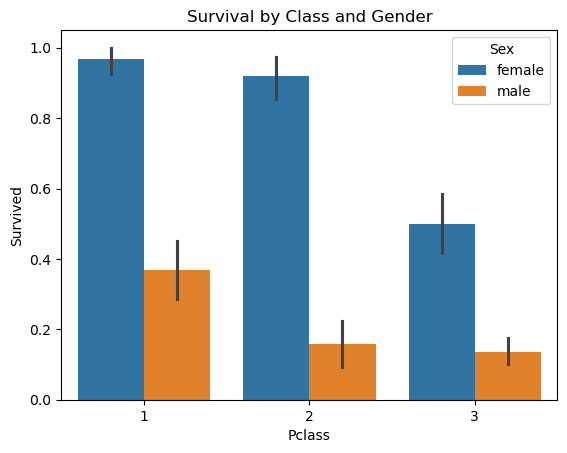

In [17]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title('Survival by Class and Gender')
plt.show()

### Key Findings
- Female passengers maintained higher survival rates across all classes.
- Third-class females experienced lower survival rates than first-class females.
- Male passengers had consistently low survival outcomes across classes.

### Interpretation
While gender strongly influenced survival outcomes, socioeconomic status moderated this advantage. Lower-class passengers faced structural disadvantages regardless of gender.

## Age and Class

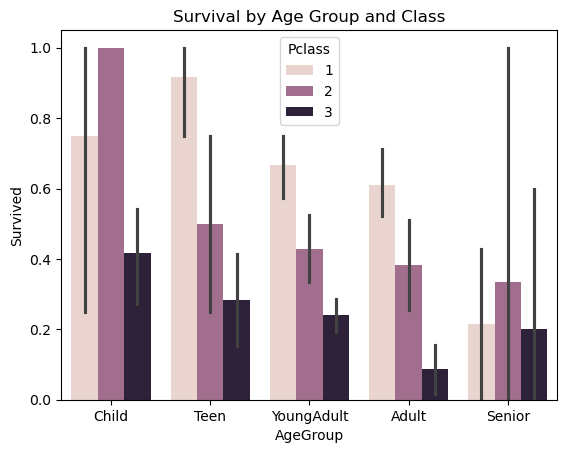

In [18]:
sns.barplot(x='AgeGroup', y='Survived', hue='Pclass', data=df)
plt.title('Survival by Age Group and Class')
plt.show()

### Interpretation
The survival advantage observed among children was significantly reduced in third class, indicating that class-based inequalities affected even prioritized demographic groups.

---

# 10. Conclusion

## Summary of Findings
The analysis demonstrates that survival aboard the Titanic was not random. Instead, survival outcomes were strongly influenced by demographic and socioeconomic factors.

### Primary Factors Influencing Survival
1. Gender
2. Passenger class
3. Fare/wealth
4. Age
5. Family structure

## Final Interpretation
Female passengers and higher-class passengers consistently demonstrated significantly higher survival rates, indicating that both evacuation policies and socioeconomic status influenced rescue outcomes. While children were prioritized to some extent, class-based inequalities remained highly influential.

Overall, the findings suggest that access to survival resources aboard the Titanic was shaped by a combination of social prioritization and structural inequality.

---

# Future Improvements

Potential future extensions of this project include:

- Statistical significance testing
- Interactive dashboards
- SQL-based analysis workflows
- Predictive Modeling